In [3]:
!pip install matplotlib seaborn scikit-learn pandas --break-system-packages

In [38]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [39]:
def get_na(data):
    for column in data.columns:
        print("column: ", column, "; total=", data[column].isnull().sum())

In [40]:
def check_proportion(data):

    grouped_data = data.groupby("sex")["alive"].value_counts()
    total = grouped_data.values.sum()
    sex = [ di[0] for di in grouped_data.index ]
    alive = [ di[1] for di in grouped_data.index ]
    values = grouped_data.values
    
    new_data = pd.DataFrame({"sex":sex, "alive":alive, "values":values})
    ax = sns.barplot(data=new_data, x="alive", y="values", hue="sex")


    for p in ax.patches:
        height = p.get_height()
        if(height <= 0):
            continue
        label = f"{(height/total)*100:.2f}%"
        
        ax.text(p.get_x() + p.get_width() / 2, height, label, ha='center', va='bottom', fontsize=12)

    plt.show()

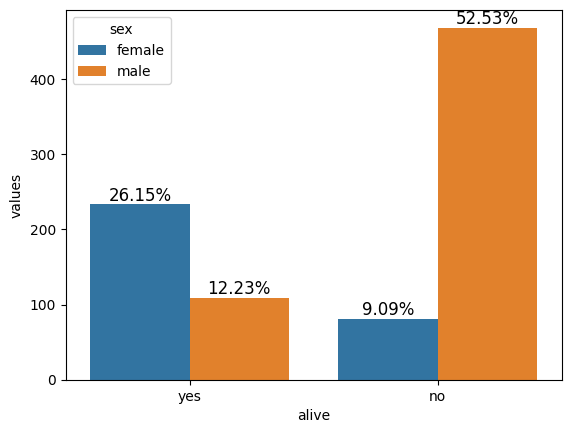

In [83]:
data = sns.load_dataset("titanic")
check_proportion(data)


In [84]:

data.deck = data.deck.cat.add_categories("H").fillna("H")
data.embark_town = data.embark_town.fillna("O")
data.embarked = data.embark_town.fillna("N")

data = data.dropna()
get_na(data)

data.shape

column:  survived ; total= 0
column:  pclass ; total= 0
column:  sex ; total= 0
column:  age ; total= 0
column:  sibsp ; total= 0
column:  parch ; total= 0
column:  fare ; total= 0
column:  embarked ; total= 0
column:  class ; total= 0
column:  who ; total= 0
column:  adult_male ; total= 0
column:  deck ; total= 0
column:  embark_town ; total= 0
column:  alive ; total= 0
column:  alone ; total= 0


(714, 15)

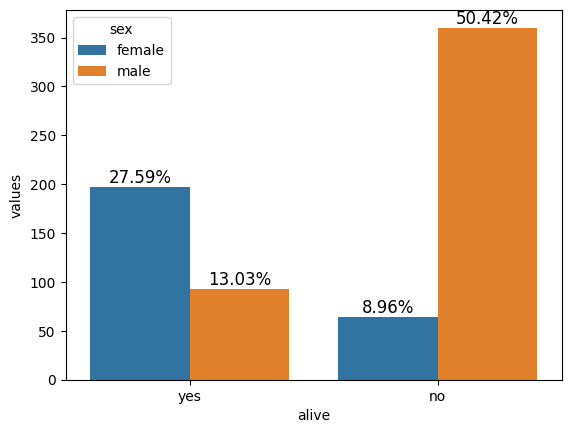

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,Southampton,Third,man,True,H,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,Cherbourg,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,Southampton,Third,woman,False,H,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,Southampton,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,Southampton,Third,man,True,H,Southampton,no,True


In [85]:
check_proportion(data)
data.head()

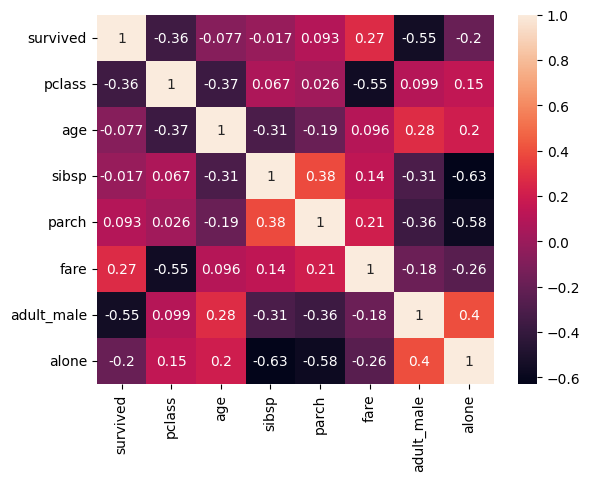

In [44]:
sns.heatmap(data.corr(numeric_only=True), annot=True)
plt.show()

In [45]:
data.who.unique()

array(['man', 'woman', 'child'], dtype=object)

----

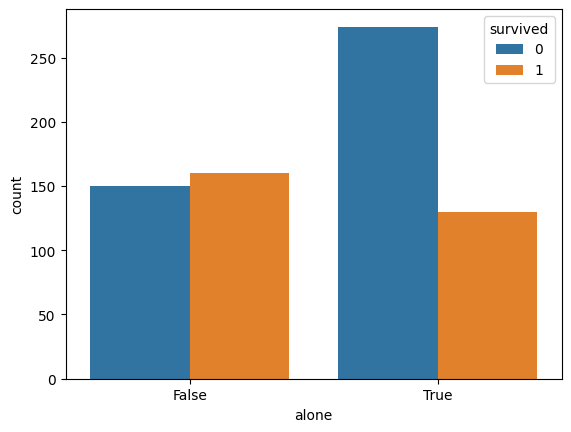

In [46]:
sns.countplot(data=data, x="alone", hue="survived")
plt.show()

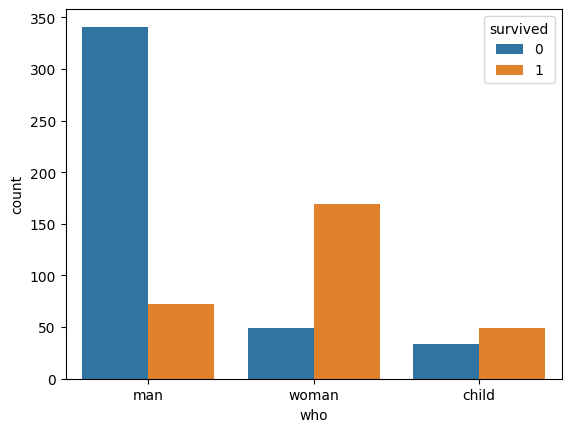

In [47]:
sns.countplot(data=data, x="who", hue="survived")
plt.show()

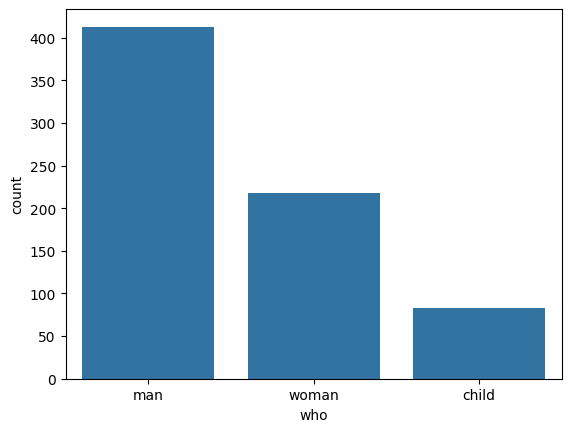

In [48]:
sns.countplot(data=data, x="who")
plt.show()

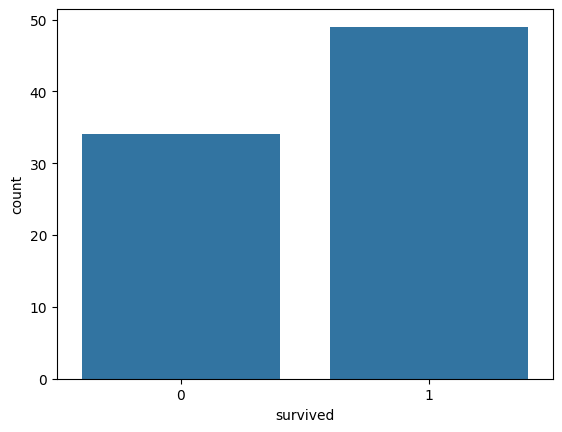

In [49]:
only_children = data.loc[data.who == "child"]
sns.countplot(data=only_children, x="survived")
plt.show()

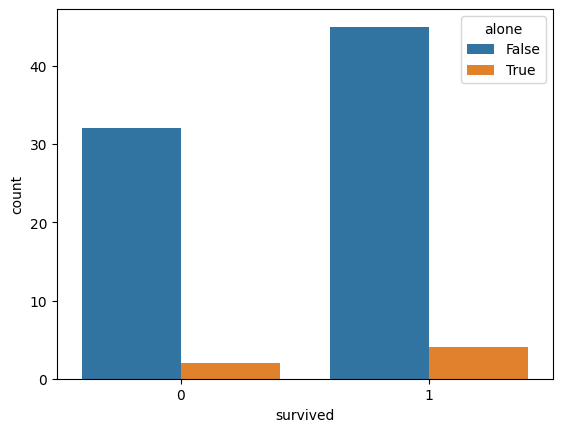

In [50]:
sns.countplot(data=only_children, x="survived", hue="alone")
plt.show()

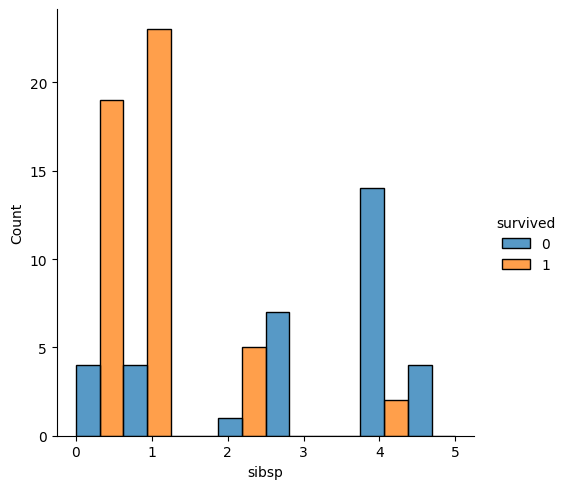

In [51]:
sns.displot(data=only_children, x="sibsp", hue="survived", multiple="dodge")
plt.show()

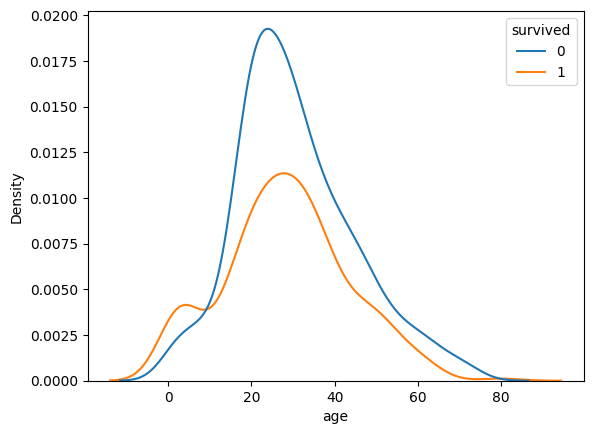

In [52]:
sns.kdeplot(data=data, x="age", hue="survived")
plt.show()

In [53]:
only_woman = data.loc[data.who == "woman"]
only_man = data.loc[data.who == "man"]

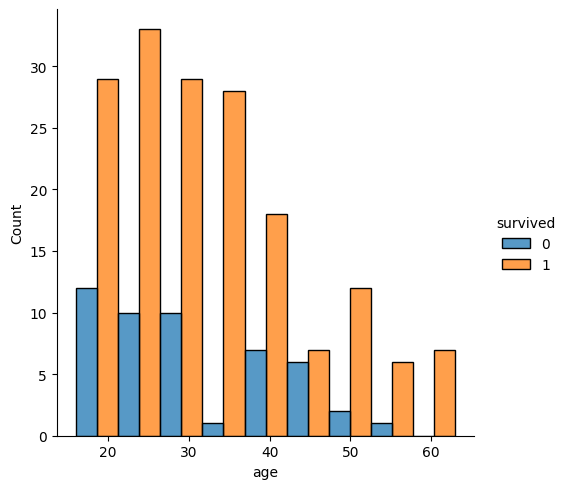

In [54]:
sns.displot(data=only_woman, x="age",hue="survived",multiple="dodge")
plt.show()

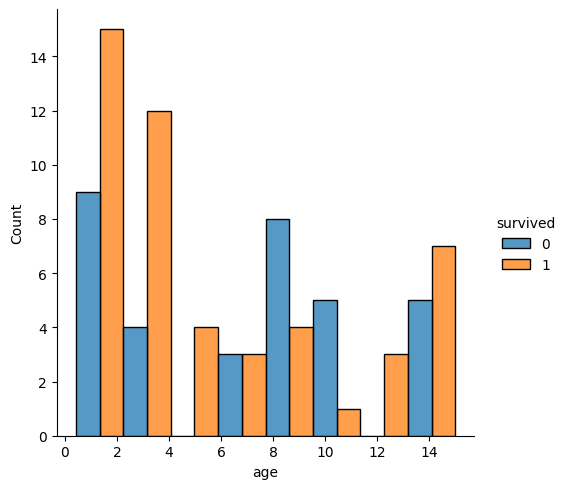

In [55]:
sns.displot(data=only_children, x="age",hue="survived",multiple="dodge")
plt.show()

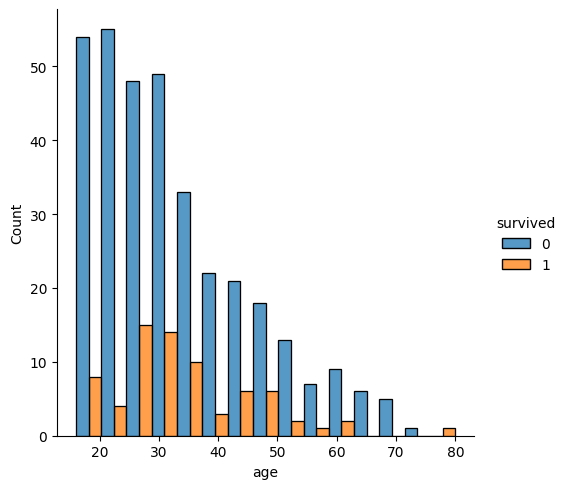

In [56]:
sns.displot(data=only_man, x="age", hue="survived", multiple="dodge")
plt.show()

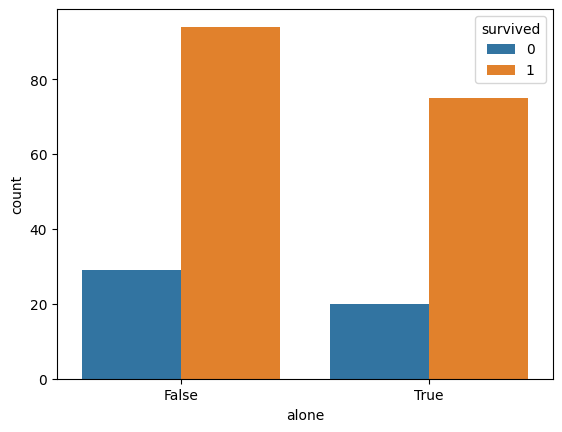

In [57]:
sns.countplot(data=only_woman, x="alone", hue="survived")
plt.show()

In [58]:
child_and_woman_together = data.copy()
child_and_woman_together.loc[child_and_woman_together.who != "man", "who"] = "survivor"

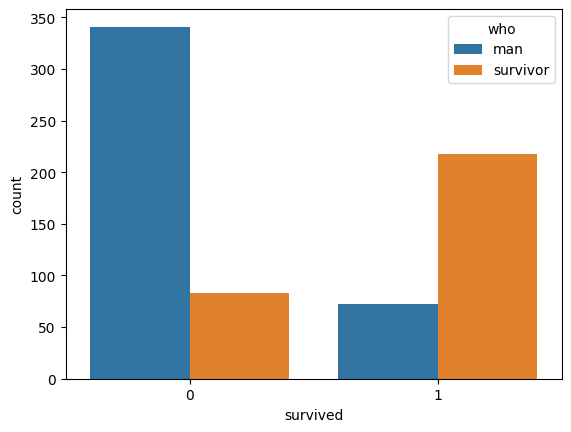

In [59]:
sns.countplot(data=child_and_woman_together, x="survived", hue="who")
plt.show()

### Mulheres e crianças sobreviveram na maioria

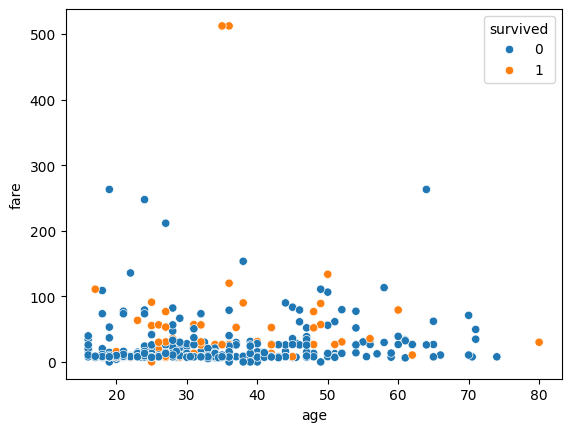

In [60]:
sns.scatterplot(data=only_man, x="age", y="fare", hue="survived")
plt.show()

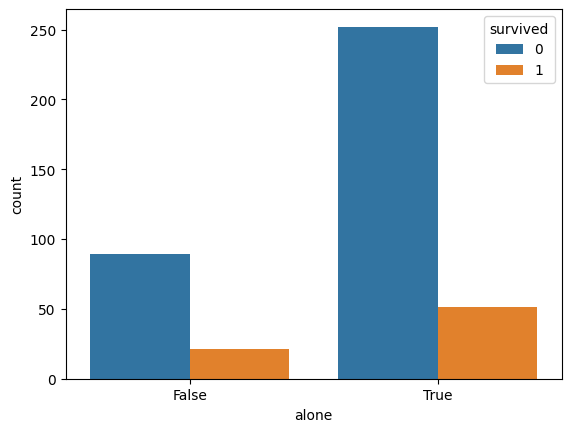

In [61]:
sns.countplot(data=only_man, x="alone", hue="survived")
plt.show()

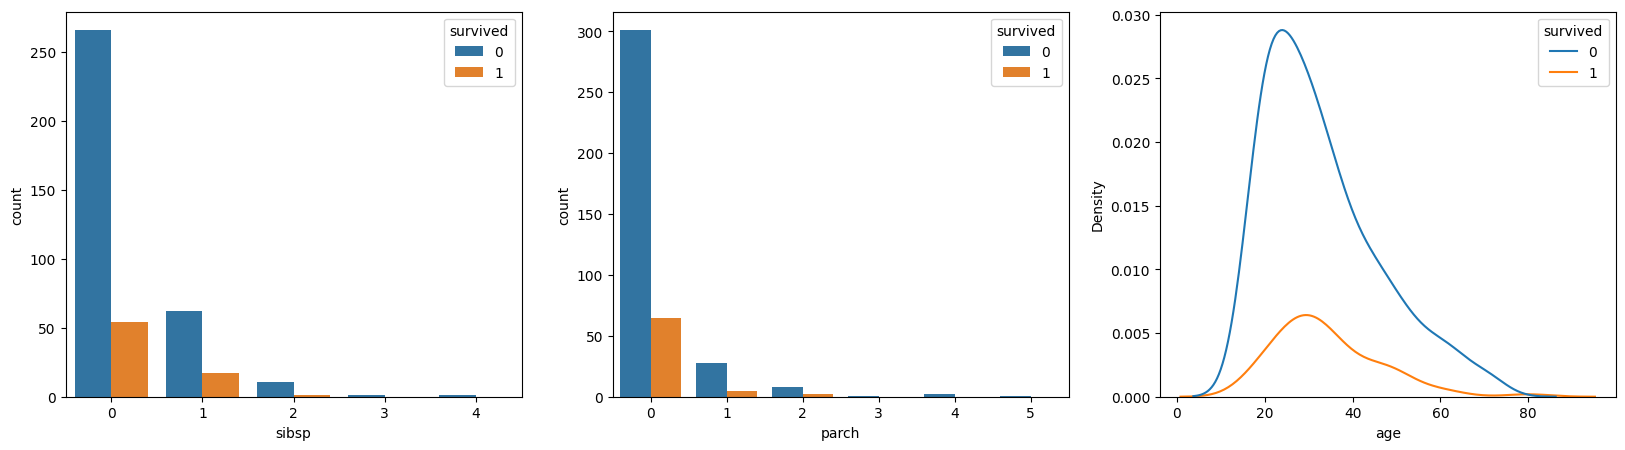

In [62]:
fig,ax = plt.subplots(1,3,figsize=(20,5))
sns.countplot(data=only_man, x="sibsp", hue="survived", ax=ax[0])
sns.countplot(data=only_man, x="parch", hue="survived", ax=ax[1])
sns.kdeplot(data=only_man, x="age", hue="survived", ax=ax[2])
plt.show()

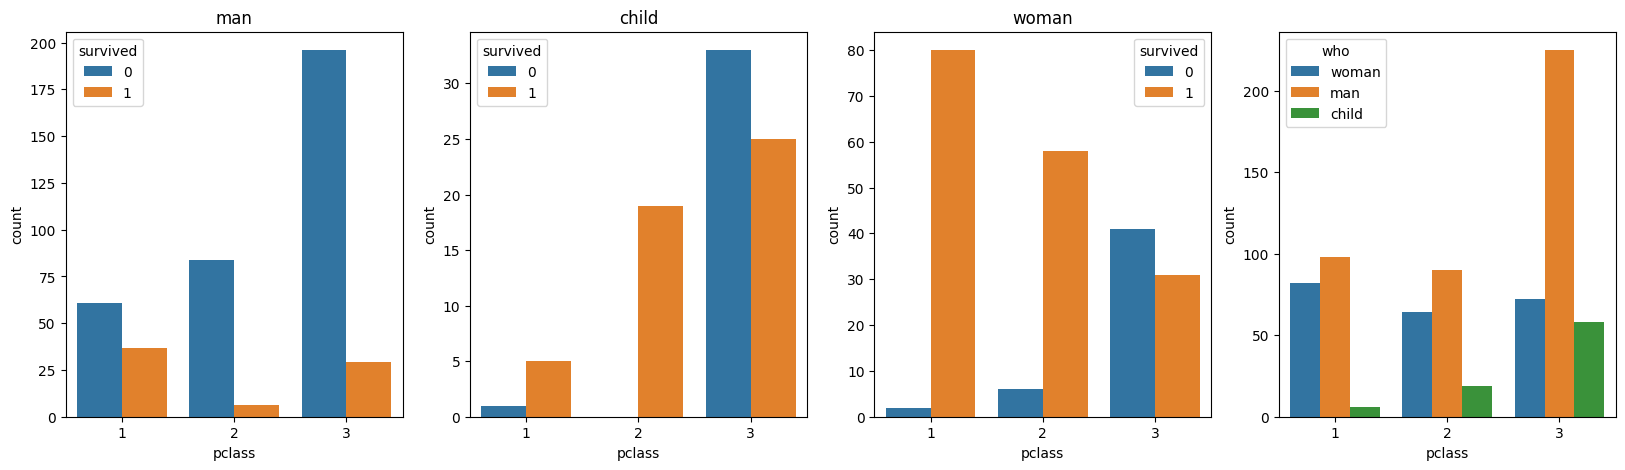

In [63]:
fig,ax = plt.subplots(1,4,figsize=(20,5))
sns.countplot(data=only_man, x="pclass", hue="survived", ax=ax[0])
sns.countplot(data=only_children, x="pclass", hue="survived", ax=ax[1])
sns.countplot(data=only_woman, x="pclass", hue="survived", ax=ax[2])
sns.countplot(data=data, x="pclass", hue="who", ax=ax[3])

ax[0].set_title("man")
ax[1].set_title("child")
ax[2].set_title("woman")


plt.show()

### Classe e número de irmãos também está ligado 

In [86]:
from sklearn.preprocessing import OneHotEncoder
enc = OneHotEncoder(drop="first", sparse_output=False)
encoded_data = enc.fit_transform(data.who.values.reshape(-1,1))

In [88]:
encoded_data

array([[1., 0.],
       [0., 1.],
       [0., 1.],
       ...,
       [0., 1.],
       [1., 0.],
       [1., 0.]], shape=(714, 2))

In [90]:
feature_names = enc.get_feature_names_out(['who'])
feature_names

array(['who_man', 'who_woman'], dtype=object)

In [91]:
encoded_who = pd.DataFrame(encoded_data, columns=feature_names)
encoded_who.head()

,who_man,who_woman
0,1.0,0.0
1,0.0,1.0
2,0.0,1.0
3,0.0,1.0
4,1.0,0.0


In [101]:
data = pd.concat([data.reset_index(drop=True),encoded_who.reset_index(drop=True)],axis=1)
get_na(data)
new_data.head()

column:  survived ; total= 0
column:  pclass ; total= 0
column:  sex ; total= 0
column:  age ; total= 0
column:  sibsp ; total= 0
column:  parch ; total= 0
column:  fare ; total= 0
column:  embarked ; total= 0
column:  class ; total= 0
column:  who ; total= 0
column:  adult_male ; total= 0
column:  deck ; total= 0
column:  embark_town ; total= 0
column:  alive ; total= 0
column:  alone ; total= 0
column:  who_man ; total= 0
column:  who_woman ; total= 0


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,who_man,who_woman
0,0,3,male,22.0,1,0,7.2500,Southampton,Third,man,True,H,Southampton,no,False,1.0,0.0
1,1,1,female,38.0,1,0,71.2833,Cherbourg,First,woman,False,C,Cherbourg,yes,False,0.0,1.0
2,1,3,female,26.0,0,0,7.9250,Southampton,Third,woman,False,H,Southampton,yes,True,0.0,1.0
3,1,1,female,35.0,1,0,53.1000,Southampton,First,woman,False,C,Southampton,yes,False,0.0,1.0
4,0,3,male,35.0,0,0,8.0500,Southampton,Third,man,True,H,Southampton,no,True,1.0,0.0


In [103]:
data.loc[data.who == "child"].head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,who_man,who_woman
6,0,3,male,2.0,3,1,21.0750,Southampton,Third,child,False,H,Southampton,no,False,0.0,0.0
8,1,2,female,14.0,1,0,30.0708,Cherbourg,Second,child,False,H,Cherbourg,yes,False,0.0,0.0
9,1,3,female,4.0,1,1,16.7000,Southampton,Third,child,False,G,Southampton,yes,False,0.0,0.0
13,0,3,female,14.0,0,0,7.8542,Southampton,Third,child,False,H,Southampton,no,True,0.0,0.0
15,0,3,male,2.0,4,1,29.1250,Queenstown,Third,child,False,H,Queenstown,no,False,0.0,0.0


In [104]:
selected_cols = ["pclass","sibsp","who_man", "who_woman"]

In [105]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(data[selected_cols],data["survived"])

In [106]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

In [107]:
model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [108]:
pred = model.predict(X_test)

In [109]:
from sklearn.metrics import accuracy_score, classification_report 

In [110]:
print(accuracy_score(y_test,pred))
print(classification_report(y_test, pred))

0.8156424581005587
              precision    recall  f1-score   support

           0       0.81      0.88      0.84        99
           1       0.83      0.74      0.78        80

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.81       179

